# Part A: CVAE Improvements and Experiments

Previously, we trained a baseline CVAE that had somewhat mediocre performance. In this notebook, we experiment with different model architectures and settings to produce a much more fine-tuned and improved model.


## 1. Imports and Setup


In [37]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import pandas as pd
import json
from torch.utils.data import TensorDataset, DataLoader
from torchvision.datasets import CIFAR10

# Set random seed for reproducibility.
torch.manual_seed(42)
np.random.seed(42)

In [38]:
import seaborn as sns

# Shared design system for all notebooks in dele/: a 10-color categorical palette
# (one hue per CIFAR10 class), validated for lightness, chroma, and colorblind
# separation with the dataviz skill's validator (all checks pass).
PALETTE = [
    "#A1533F",  # 0 airplane   - terracotta
    "#C08A3E",  # 1 automobile - ochre
    "#3D8049",  # 2 bird       - sage
    "#24558F",  # 3 cat        - slate blue
    "#8A3466",  # 4 deer       - plum
    "#4552A8",  # 5 dog        - indigo
    "#8C3F32",  # 6 frog       - brick red
    "#B79A2E",  # 7 horse      - mustard
    "#B5615B",  # 8 ship       - rose
    "#6B7A1A",  # 9 truck      - olive
]
sns.set_theme(style="whitegrid", palette=PALETTE)
plt.rcParams["figure.facecolor"] = "#fcfcfb"
plt.rcParams["axes.facecolor"] = "#fcfcfb"

In [39]:
# Re-define the baseline's Sampling/Encoder/Decoder/CVAE builders here (self-contained, no shared .py) so each experiment can vary one of them.
class Sampling(nn.Module):
    """Reparameterization trick: z = z_mean + std * epsilon, epsilon ~ N(0, 1)."""

    def forward(self, z_mean, z_log_var):
        std = torch.exp(0.5 * z_log_var)
        epsilon = torch.randn_like(std)
        return z_mean + std * epsilon


class Encoder(nn.Module):
    def __init__(self, num_classes, latent_dim):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(3 + num_classes, 32, kernel_size=3, stride=2, padding=1),  # 32x32 -> 16x16
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1),  # 16x16 -> 8x8
            nn.ReLU(),
        )
        self.fc_mean = nn.Linear(64 * 8 * 8, latent_dim)
        self.fc_log_var = nn.Linear(64 * 8 * 8, latent_dim)
        self.sampling = Sampling()

    def forward(self, x, y):
        # Broadcast the one-hot label into a spatial map so it can be concatenated as extra input channels.
        y_map = y.view(y.size(0), -1, 1, 1).expand(-1, -1, x.size(2), x.size(3))
        x = torch.cat([x, y_map], dim=1)

        features = self.conv(x).flatten(start_dim=1)
        z_mean = self.fc_mean(features)
        z_log_var = self.fc_log_var(features)
        z = self.sampling(z_mean, z_log_var)
        return z_mean, z_log_var, z


class Decoder(nn.Module):
    def __init__(self, num_classes, latent_dim):
        super().__init__()
        self.fc = nn.Linear(latent_dim + num_classes, 64 * 8 * 8)
        self.deconv = nn.Sequential(
            nn.ConvTranspose2d(64, 32, kernel_size=3, stride=2, padding=1, output_padding=1),  # 8x8 -> 16x16
            nn.ReLU(),
            nn.ConvTranspose2d(32, 3, kernel_size=3, stride=2, padding=1, output_padding=1),  # 16x16 -> 32x32
            nn.Sigmoid(),
        )

    def forward(self, z, y):
        # No spatial grid to broadcast into yet, so the label is concatenated directly onto z instead.
        x = torch.cat([z, y], dim=1)
        x = self.fc(x).view(-1, 64, 8, 8)
        return self.deconv(x)


class CVAE(nn.Module):
    def __init__(self, encoder, decoder, kl_weight=1.0):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.kl_weight = kl_weight

    def forward(self, x, y):
        z_mean, z_log_var, z = self.encoder(x, y)
        reconstruction = self.decoder(z, y)
        return reconstruction, z_mean, z_log_var

    def loss(self, x, y):
        reconstruction, z_mean, z_log_var = self(x, y)

        # Summed BCE + closed-form Gaussian KL, matching the baseline's loss formulation exactly so losses stay comparable.
        reconstruction_loss = F.binary_cross_entropy(reconstruction, x, reduction="sum") / x.size(0)
        kl_loss = -0.5 * torch.sum(1 + z_log_var - z_mean.pow(2) - z_log_var.exp(), dim=1).mean()
        total_loss = reconstruction_loss + self.kl_weight * kl_loss

        return total_loss, reconstruction_loss, kl_loss


# GPU if available, since every experiment retrains a full CVAE from scratch.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

device: cuda


In [53]:
# train_cvae(): same training loop as the baseline, reused by every experiment below instead of rewriting it each time.
# Experiments don't save checkpoints to disk (only the baseline and final model do), so this just returns the trained model + history.
def train_cvae(cvae, num_epochs=30, batch_size=128, lr=1e-3):
    cvae = cvae.to(device)
    x_train_dev, y_train_dev = x_train.to(device), y_train_onehot.to(device)
    x_val_dev, y_val_dev = x_val.to(device), y_val_onehot.to(device)

    train_loader = DataLoader(TensorDataset(x_train_dev, y_train_dev), batch_size=batch_size, shuffle=True)
    optimizer = torch.optim.Adam(cvae.parameters(), lr=lr)
    history = {"train_loss": [], "val_loss": []}

    for epoch in range(num_epochs):
        cvae.train()
        train_loss = 0.0
        for xb, yb in train_loader:
            optimizer.zero_grad()
            loss, _, _ = cvae.loss(xb, yb)
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * len(xb)
        train_loss /= len(x_train_dev)

        cvae.eval()
        with torch.no_grad():
            val_loss, _, _ = cvae.loss(x_val_dev, y_val_dev)
        val_loss = val_loss.item()

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)

    print(f"trained {num_epochs} epochs - final train_loss: {history['train_loss'][-1]:.2f} - final val_loss: {history['val_loss'][-1]:.2f}")
    return cvae, history


# generate_class_images(): sample images_per_class fresh images per class from the prior, same recipe as the baseline's Section 10.1.
def generate_class_images(cvae, latent_dim, images_per_class=10):
    labels_onehot = torch.eye(num_classes, device=device)
    images, labels = [], []

    cvae.eval()
    with torch.no_grad():
        for class_idx in range(num_classes):
            z = torch.randn(images_per_class, latent_dim, device=device)
            y = labels_onehot[class_idx : class_idx + 1].repeat(images_per_class, 1)
            images.append(cvae.decoder(z, y))
            labels.append(torch.full((images_per_class,), class_idx))

    return torch.cat(images), torch.cat(labels)


# preview_grid(): show a small class x images grid for eye-test scoring, same layout as the baseline's Section 11.1.
def preview_grid(images, labels, n_per_class=10, title=None):
    fig, axes = plt.subplots(num_classes, n_per_class, figsize=(n_per_class * 1.2, num_classes * 1.2))
    for class_idx, class_name in enumerate(class_names):
        class_images = images[labels == class_idx][:n_per_class]
        for col in range(n_per_class):
            axes[class_idx, col].imshow(class_images[col].permute(1, 2, 0).cpu().numpy())
            axes[class_idx, col].set_xticks([])
            axes[class_idx, col].set_yticks([])
            if col == 0:
                axes[class_idx, col].set_ylabel(class_name, fontsize=9)
    if title:
        fig.suptitle(title)
    plt.tight_layout()
    plt.show()

## 2. Load Baseline Results

We load the previous VAE model's results that were saved: the config, the loss values, and the eye-test scores.


In [41]:
# Load CIFAR10 and apply the same preprocessing (normalize, one-hot, val split) as the baseline notebook.
train_set = CIFAR10(root="..", train=True, download=True)
test_set = CIFAR10(root="..", train=False, download=True)
class_names = train_set.classes
num_classes = len(class_names)

# Channel-first (N, C, H, W) layout, expected by torch's Conv2d layers.
x_train = torch.tensor(train_set.data, dtype=torch.float32).permute(0, 3, 1, 2) / 255
x_test = torch.tensor(test_set.data, dtype=torch.float32).permute(0, 3, 1, 2) / 255
y_train = torch.tensor(train_set.targets, dtype=torch.long)
y_test = torch.tensor(test_set.targets, dtype=torch.long)

# One-hot vectors give the encoder/decoder a fixed-length conditioning signal instead of a raw class index.
y_train_onehot = F.one_hot(y_train, num_classes=num_classes).float()
y_test_onehot = F.one_hot(y_test, num_classes=num_classes).float()

# Same fixed seed as the baseline, so the same 5000 images are held out as validation and results stay comparable.
val_size = 5000
generator = torch.Generator().manual_seed(42)
perm = torch.randperm(len(x_train), generator=generator)
val_idx, train_idx = perm[:val_size], perm[val_size:]

x_val, y_val, y_val_onehot = x_train[val_idx], y_train[val_idx], y_train_onehot[val_idx]
x_train, y_train, y_train_onehot = x_train[train_idx], y_train[train_idx], y_train_onehot[train_idx]

print("train:", x_train.shape, "val:", x_val.shape, "test:", x_test.shape)

train: torch.Size([45000, 3, 32, 32]) val: torch.Size([5000, 3, 32, 32]) test: torch.Size([10000, 3, 32, 32])


In [42]:
# Load the baseline's saved JSON (config, final losses, eye-test scores) for reference throughout this notebook.
with open("vae_baseline_results.json") as f:
    baseline_results = json.load(f)

print("baseline latent_dim:", baseline_results["latent_dim"], "kl_weight:", baseline_results["kl_weight"])
print("baseline final_val_loss:", baseline_results["final_val_loss"])

baseline latent_dim: 128 kl_weight: 1.0
baseline final_val_loss: 1820.45


## 3. Comparison Metrics

Before running any experiment, we explicitly define what we're measuring: how much "better" our model has performed, and how to quantify that improvement against the baseline and the other models.


### 3.1 Quality Score (primary metric)

We convert each image's eye-test label into a number (clear = 1, marginal = 0.5, nonsense = 0), then average across the scored sample, per class and overall.


In [43]:
# Define score_from_labels(): map a list of clear/marginal/nonsense tallies to a 0-1 quality score, reused by every experiment.
def score_from_labels(labels):
    # Marginal counts as half-credit rather than being dropped, since it's a real (if weaker) signal of quality, not noise.
    weights = {"c": 1.0, "m": 0.5, "n": 0.0}
    return sum(weights[label] for label in labels) / len(labels)


# Recompute the baseline's score here (rather than trusting a stored number) so it uses the exact same function every experiment will use.
baseline_scores_flat = [label for scores in baseline_results["eye_test_scores"].values() for label in scores]
baseline_quality_score = score_from_labels(baseline_scores_flat)
print("baseline quality score:", round(baseline_quality_score, 3))

baseline quality score: 0.295


### 3.2 Validation Loss (secondary / diagnostic metric)

The quality score tells us whether the generated images _look_ good, but not whether the model itself trained in a healthy way. So alongside it, we track each model's final validation loss (reconstruction error + KL divergence, measured on held-out images) as a cheap, automatic check — it flags problems like overfitting or posterior collapse even when the quality score alone looks fine.

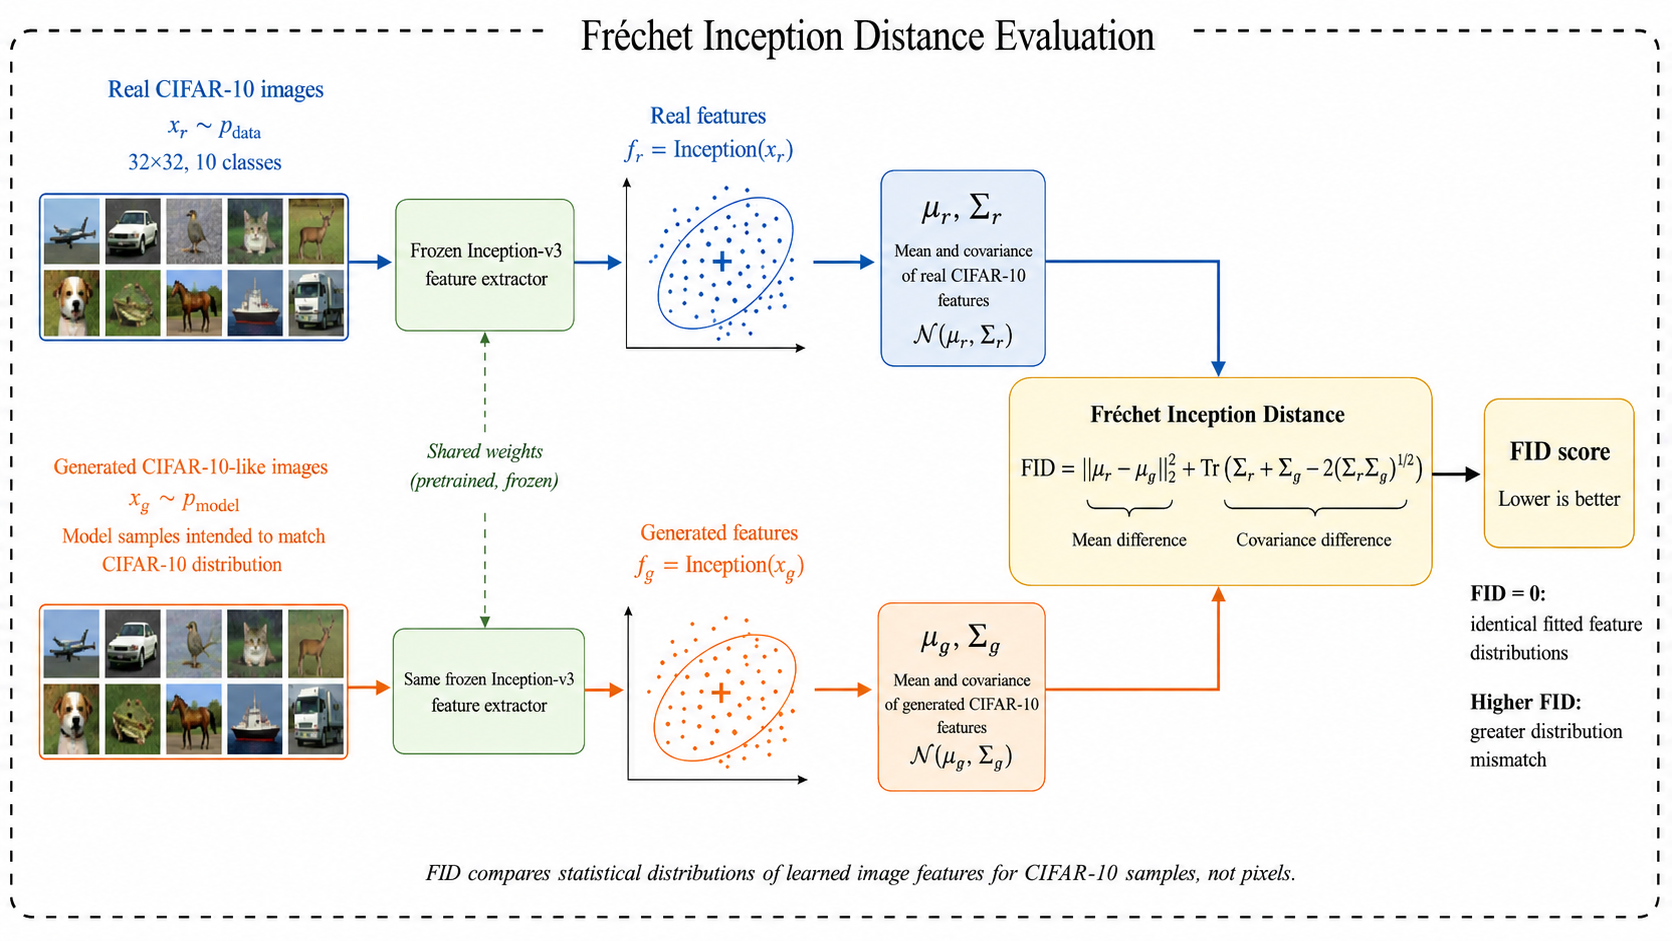

We also track FID (Fréchet Inception Distance), the standard automatic metric for generative image quality. Essentially, FID takes the mean and covariance of real and generated image features, and computes mean distance and covariance difference to produce the FID score coefficient, and a lower FID means the generated images are statistically closer to real ones. FID is loaded from the baseline's saved results and only recomputed for the Section 10 final model — it's a quantitative reference point, not something used to rank experiments 1-6.


### 3.3 Decision Rule

We define a ruleset upfront to pick a winner: quality score is the primary ranking metric, since higher quality images mean a better model. If there's a tiebreak, or a model's quality score looks strong but its validation loss shows signs of overfitting (or otherwise "cheating"), validation loss is checked as the deciding factor instead.


In [44]:
# Initialize a shared results dict (starting with the baseline's numbers) that every experiment appends its quality score and val loss to.
# Note: experiments 1-6 log metrics only and do NOT save .h5 weights — only the baseline and the Section 10 final model get saved weights.
results = {
    "baseline": {
        "quality_score": baseline_quality_score,
        "val_loss": baseline_results["final_val_loss"],
        "fid": baseline_results.get("fid"),
    }
}
results

{'baseline': {'quality_score': 0.295, 'val_loss': 1820.45, 'fid': None}}

## 4. Experiment 1: Latent Dimension

We found that the baseline's latent_dim forces CIFAR10's visually diverse classes into a latent space too small to represent them cleanly. In this experiment, we try out different latent dimensions (latent_dim = 64, 256, 512), which could raise the quality score by giving the model enough room to represent each class within the latent space.


In [60]:
# Build and train a CVAE identical to baseline except for latent_dim, for each candidate value.
latent_dim_variants = [64, 256, 512]
exp1_cvaes = {}
exp1_histories = {}

for ld in latent_dim_variants:
    encoder = Encoder(num_classes, ld)
    decoder = Decoder(num_classes, ld)
    cvae = CVAE(encoder, decoder, kl_weight=baseline_results["kl_weight"])
    exp1_cvaes[ld], exp1_histories[ld] = train_cvae(cvae)

trained 30 epochs - final train_loss: 1816.92 - final val_loss: 1819.83
trained 30 epochs - final train_loss: 1818.35 - final val_loss: 1820.86
trained 30 epochs - final train_loss: 1819.81 - final val_loss: 1822.43


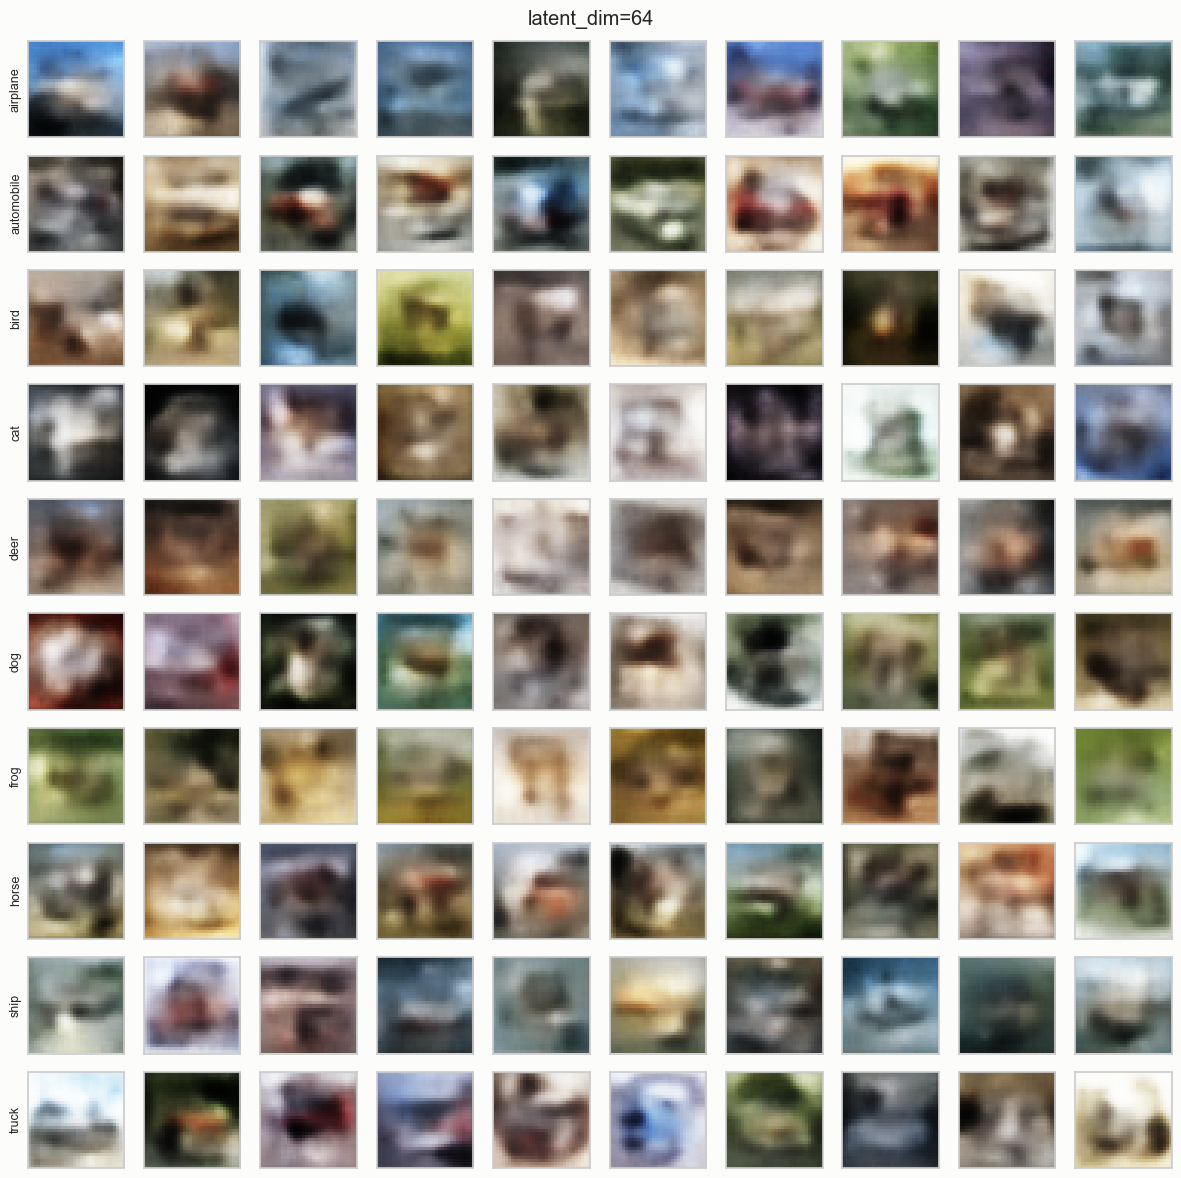

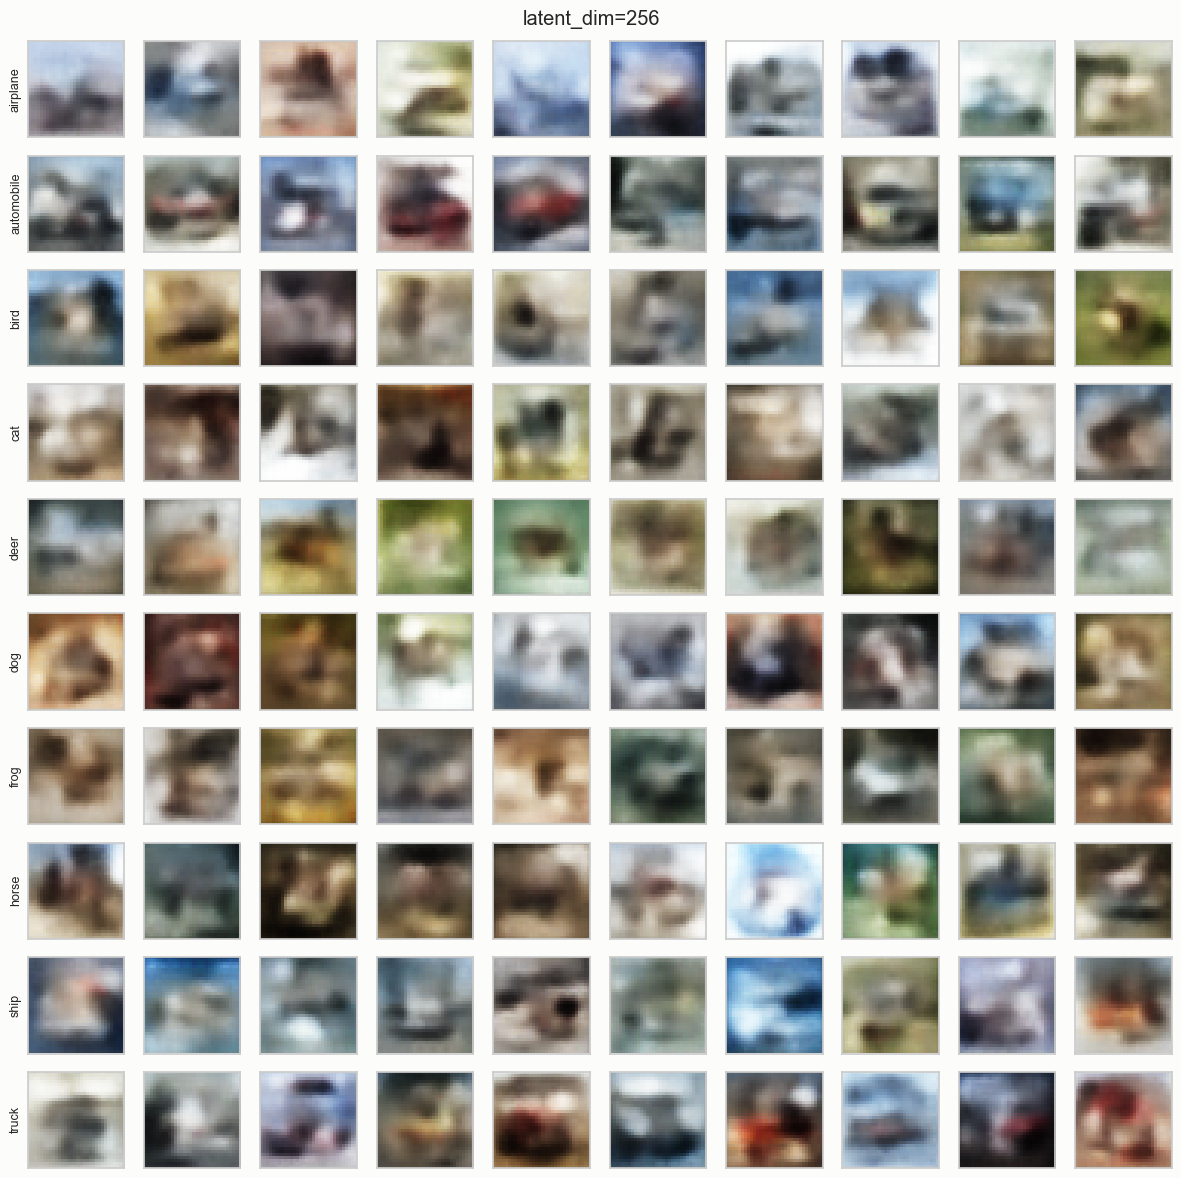

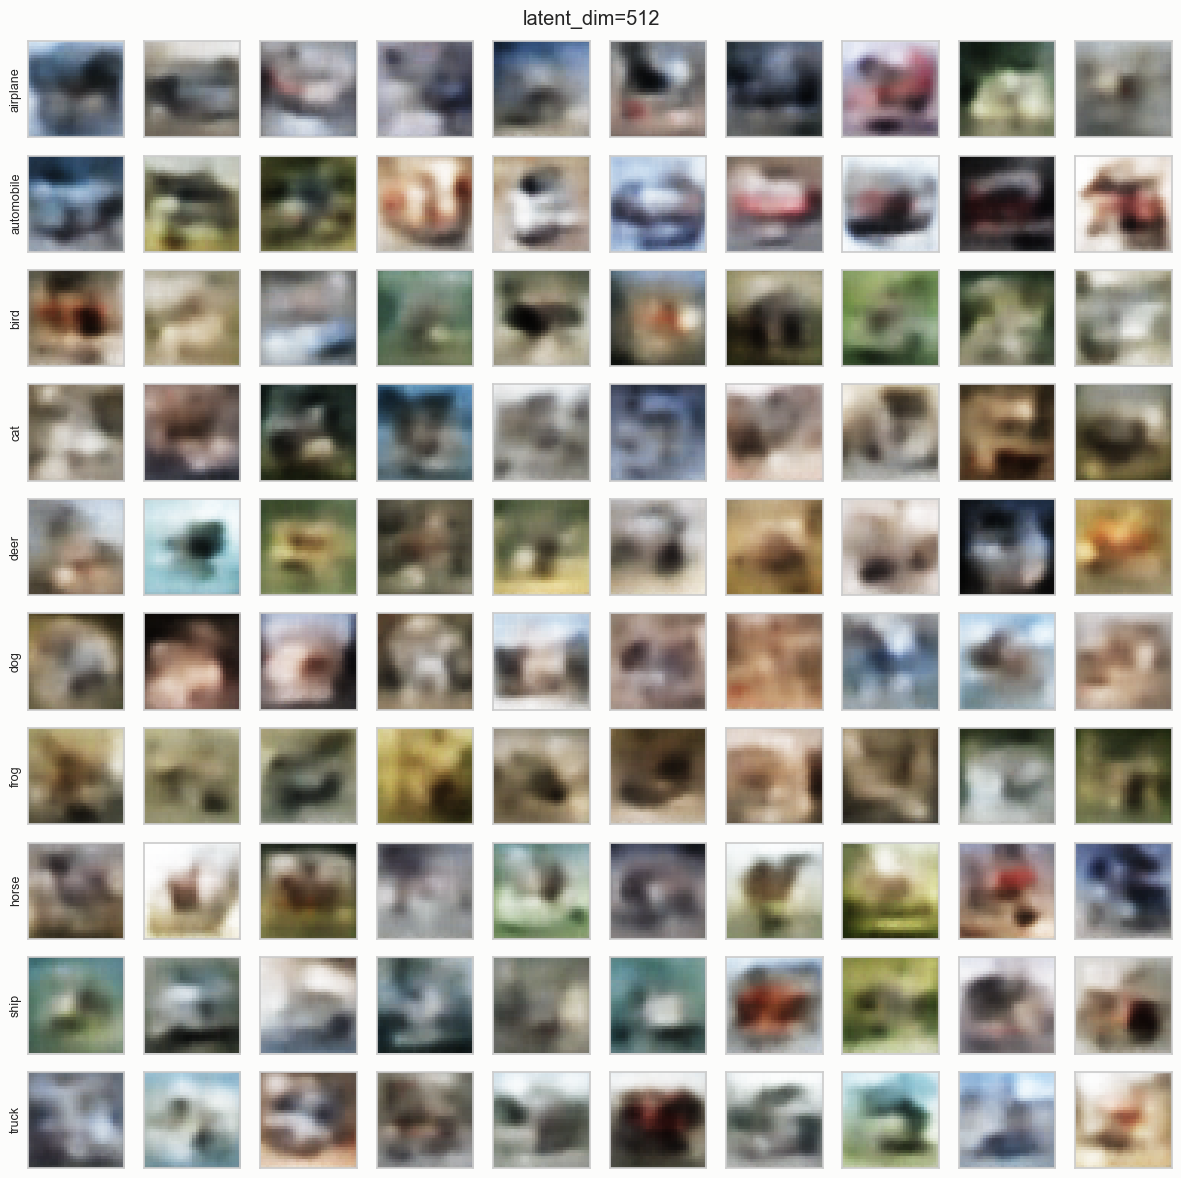

In [61]:
# Generate a sample of images per variant and preview them for eye-test scoring (same c/m/n criteria as the baseline).
exp1_images, exp1_labels = {}, {}

for ld in latent_dim_variants:
    exp1_images[ld], exp1_labels[ld] = generate_class_images(exp1_cvaes[ld], ld)
    preview_grid(exp1_images[ld], exp1_labels[ld], title=f"latent_dim={ld}")

In [65]:
# Fill in a c/m/n score for each of the 10 previewed images per class, per latent_dim variant, based on the grids above.
exp1_eye_test_scores = {
    64: {
        "airplane":   ["m", "n", "m", "m", "n", "m", "m", "n", "n", "n"],
        "automobile": ["n", "m", "c", "m", "n", "m", "m", "c", "m", "n"],
        "bird":       ["n", "n", "m", "m", "n", "n", "n", "n", "m", "m"],
        "cat":        ["n", "n", "m", "n", "m", "n", "n", "n", "n", "n"],
        "deer":       ["m", "n", "m", "m", "n", "n", "m", "m", "m", "m"],
        "dog":        ["n", "n", "n", "n", "m", "m", "n", "m", "n", "m"],
        "frog":       ["m", "m", "m", "m", "n", "m", "n", "n", "n", "n"],
        "horse":      ["m", "n", "m", "m", "m", "m", "m", "m", "c", "m"],
        "ship":       ["m", "m", "n", "m", "n", "m", "m", "m", "n", "m"],
        "truck":      ["m", "m", "c", "m", "m", "m", "n", "m", "n", "n"],
    },

    256: {
        "airplane":   ["m", "m", "m", "n", "m", "m", "n", "m", "n", "n"],
        "automobile": ["m", "m", "m", "c", "c", "n", "m", "m", "m", "n"],
        "bird":       ["m", "m", "n", "n", "n", "n", "m", "m", "m", "m"],
        "cat":        ["m", "m", "c", "m", "m", "m", "n", "m", "n", "m"],
        "deer":       ["m", "m", "c", "n", "m", "m", "m", "m", "m", "n"],
        "dog":        ["m", "m", "m", "m", "m", "m", "m", "m", "m", "m"],
        "frog":       ["m", "m", "m", "n", "m", "m", "m", "m", "m", "m"],
        "horse":      ["c", "m", "m", "m", "m", "m", "n", "m", "m", "m"],
        "ship":       ["m", "m", "m", "m", "n", "n", "m", "n", "n", "m"],
        "truck":      ["m", "m", "m", "m", "c", "m", "m", "m", "m", "c"],
    },

    512: {
        "airplane":   ["m", "m", "m", "m", "m", "m", "m", "m", "n", "n"],
        "automobile": ["m", "m", "m", "m", "m", "c", "c", "c", "c", "c"],
        "bird":       ["m", "m", "n", "m", "m", "m", "m", "m", "m", "m"],
        "cat":        ["m", "m", "m", "m", "m", "n", "m", "m", "m", "m"],
        "deer":       ["m", "m", "c", "m", "m", "m", "m", "m", "n", "m"],
        "dog":        ["m", "m", "m", "m", "m", "m", "m", "m", "m", "m"],
        "frog":       ["m", "m", "m", "m", "m", "m", "m", "m", "n", "m"],
        "horse":      ["m", "c", "c", "n", "m", "m", "c", "m", "m", "n"],
        "ship":       ["m", "m", "m", "m", "n", "m", "m", "n", "n", "m"],
        "truck":      ["m", "n", "m", "m", "m", "c", "m", "m", "n", "m"],
    },
}

In [66]:
# Score each variant with score_from_labels() (Section 3.1) and log quality score + val loss into the shared results dict.
# Drop any stale exp1_* entries first, since re-running this experiment with new latent_dim values shouldn't leave old rows behind.
for key in [k for k in results if k.startswith("exp1_latent_dim_")]:
    del results[key]

for ld in latent_dim_variants:
    scores_flat = [label for scores in exp1_eye_test_scores[ld].values() for label in scores]
    results[f"exp1_latent_dim_{ld}"] = {
        "quality_score": score_from_labels(scores_flat),
        "val_loss": exp1_histories[ld]["val_loss"][-1],
        "fid": None,  # FID is only tracked for baseline and final model
    }

pd.DataFrame(results).T

,quality_score,val_loss,fid
baseline,0.295,1820.450000,NaN
exp1_latent_dim_64,0.305,1819.828613,NaN
exp1_latent_dim_256,0.435,1820.858032,NaN
exp1_latent_dim_512,0.485,1822.430298,NaN


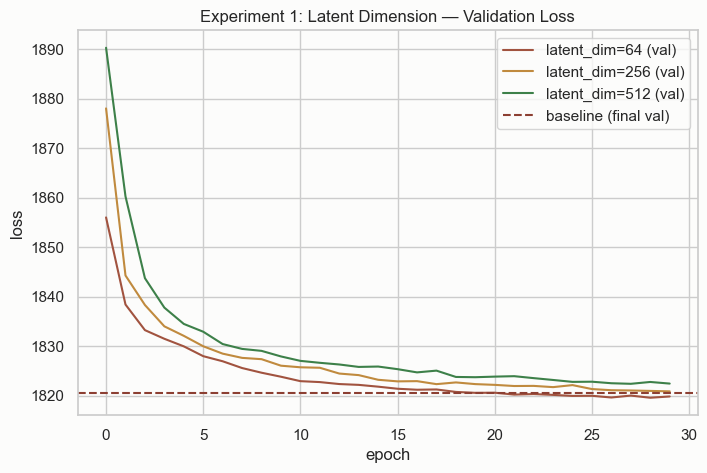

In [67]:
# Plot each variant's validation loss curve against the baseline's, on the same axes.
fig, ax = plt.subplots(figsize=(8, 5))
for i, ld in enumerate(latent_dim_variants):
    ax.plot(exp1_histories[ld]["val_loss"], label=f"latent_dim={ld} (val)", color=PALETTE[i])
ax.axhline(baseline_results["final_val_loss"], color=PALETTE[6], linestyle="--", label="baseline (final val)")
ax.set_xlabel("epoch")
ax.set_ylabel("loss")
ax.set_title("Experiment 1: Latent Dimension — Validation Loss")
ax.legend()
plt.show()

### Conclusion

Quality score rose with latent_dim as expected (64→0.305, 256→0.435, 512→0.485, vs. baseline's 0.295), but validation loss rose too instead of falling (1819.83 → 1820.86 → 1822.43) — larger latent spaces are harder to optimize in 30 epochs, though the increase is too small to signal overfitting.

latent_dim=512 wins on quality score, the primary metric, and its slightly higher loss isn't disqualifying. This also shows why quality score, not loss, should drive the decision since the two metrics disagree here.


## 5. Experiment 2: KL Weight (Beta-VAE)

We hypothesize that the baseline's kl_weight may be over-regularizing the latent space, forcing every image's encoding toward the same generic shape instead of leaving room for image-specific detail, which shows up as blurry reconstructions. So we try lower kl_weights, which we think would raise the quality score by letting the decoder produce sharper, more detailed images at the cost of a less structured latent space (less reliable smooth interpolation and random sampling), if pushed too low.


In [68]:
# Build and train a CVAE identical to baseline (same latent_dim) except for kl_weight, for each candidate value.
kl_weight_variants = [0.1, 0.3, 0.5]
exp2_cvaes = {}
exp2_histories = {}

for kw in kl_weight_variants:
    encoder = Encoder(num_classes, baseline_results["latent_dim"])
    decoder = Decoder(num_classes, baseline_results["latent_dim"])
    cvae = CVAE(encoder, decoder, kl_weight=kw)
    exp2_cvaes[kw], exp2_histories[kw] = train_cvae(cvae)

trained 30 epochs - final train_loss: 1741.08 - final val_loss: 1743.99
trained 30 epochs - final train_loss: 1768.68 - final val_loss: 1771.81
trained 30 epochs - final train_loss: 1787.51 - final val_loss: 1790.16


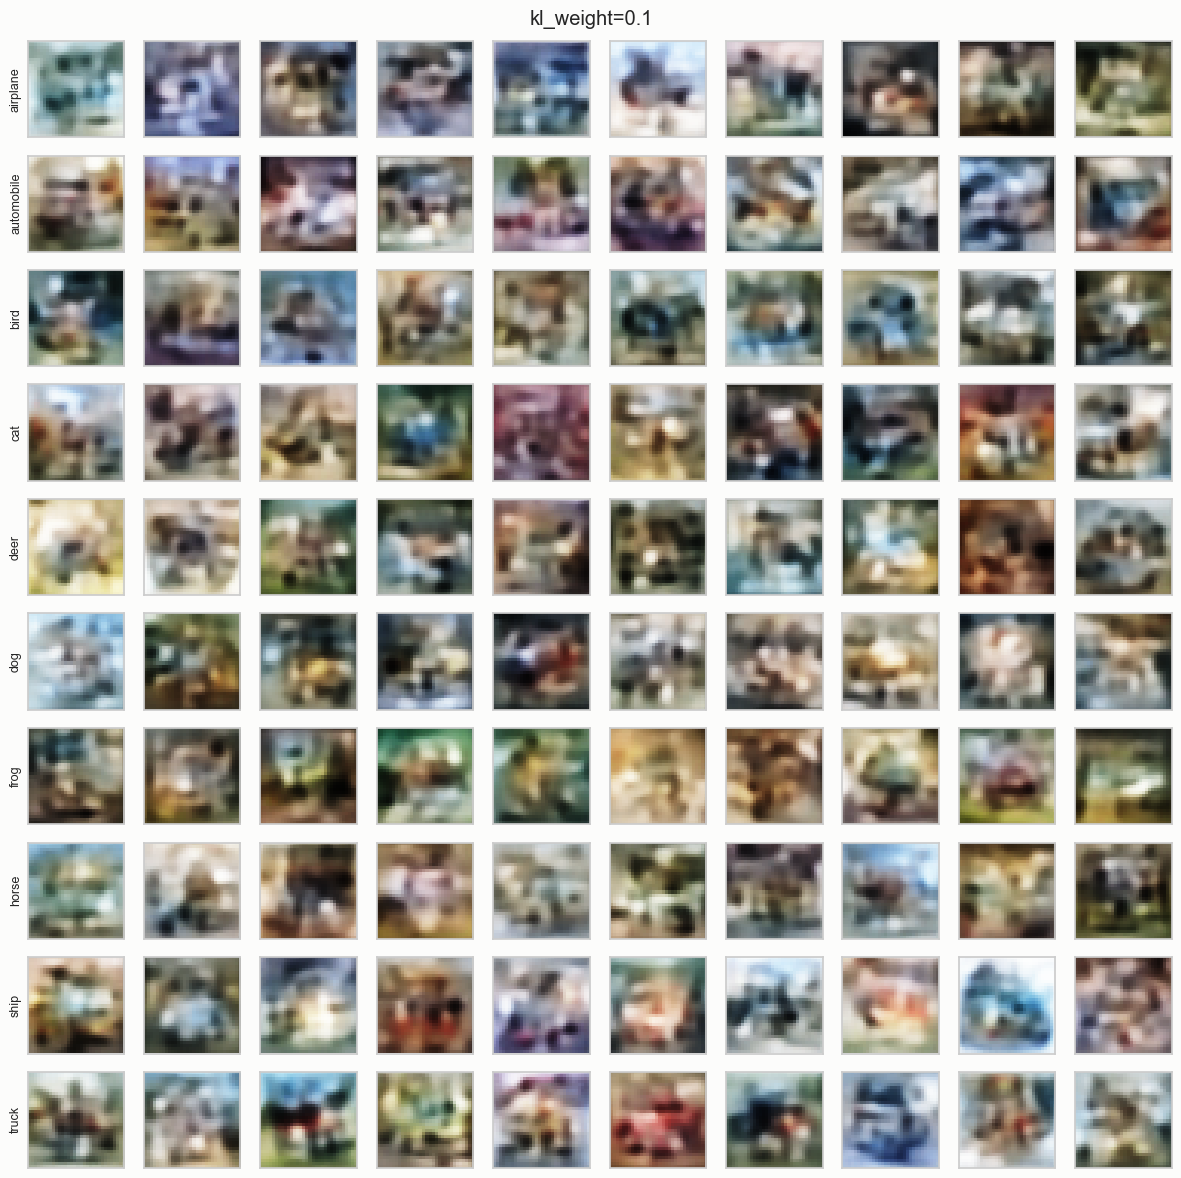

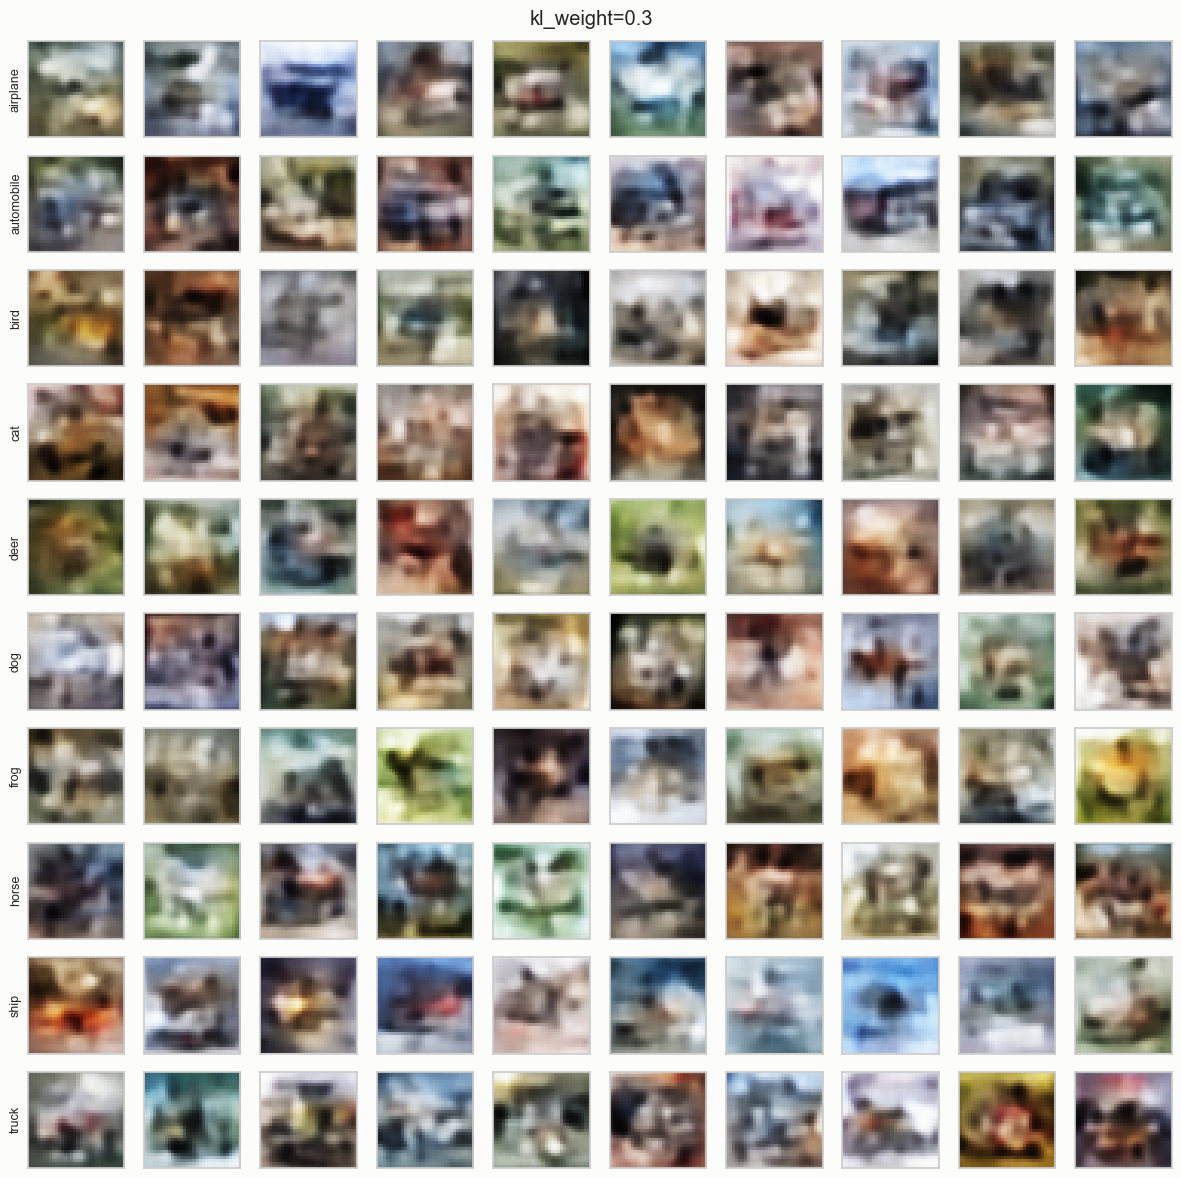

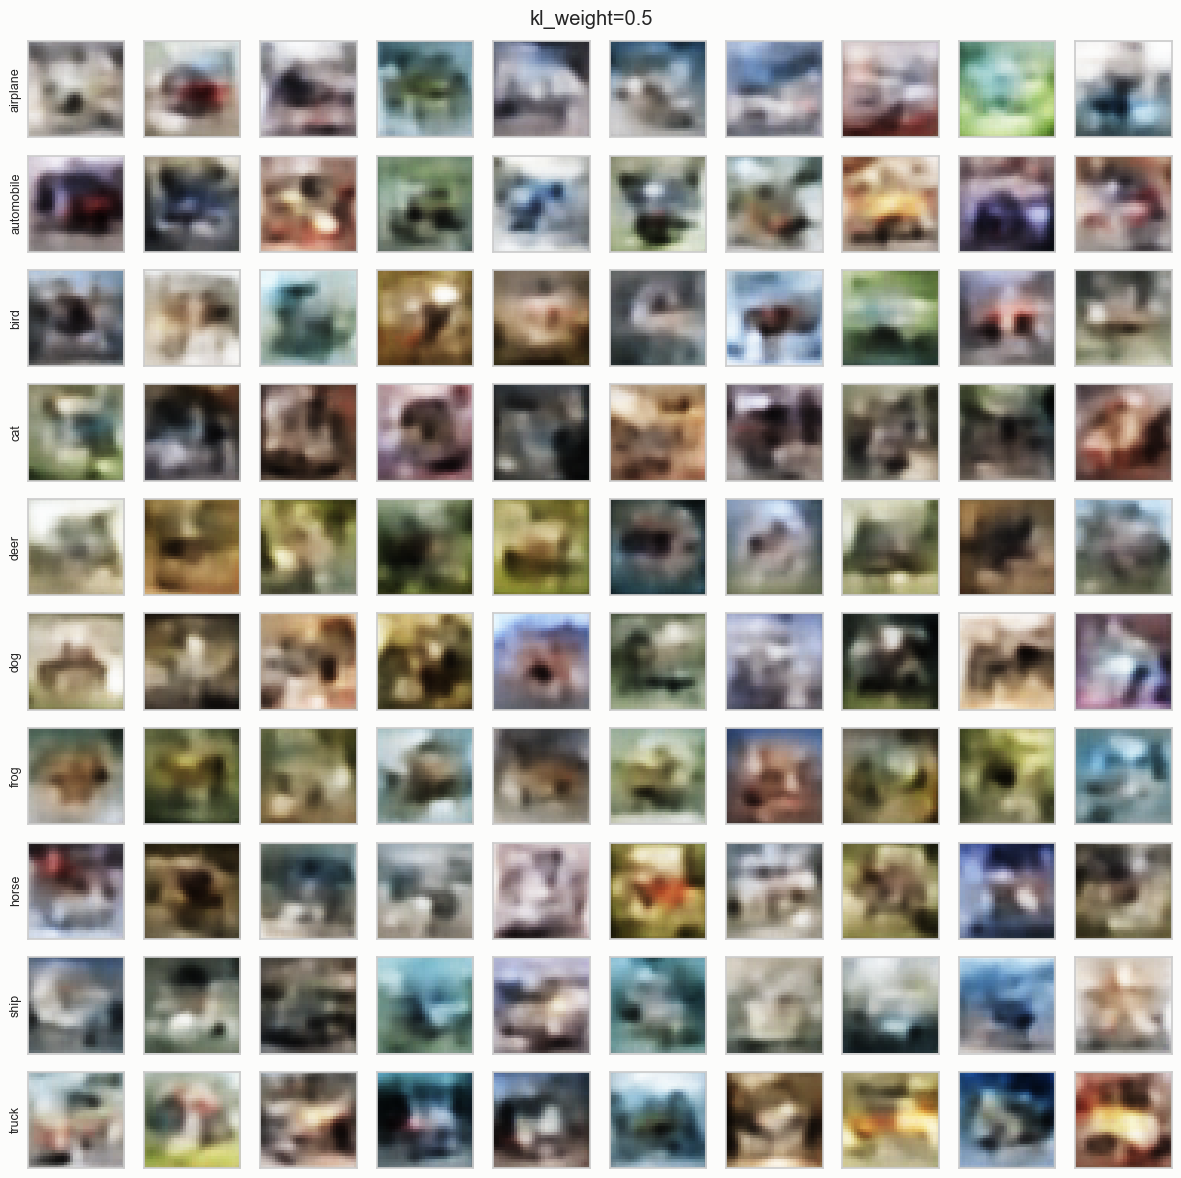

In [69]:
# Generate a sample of images per variant and preview them for eye-test scoring (same c/m/n criteria as the baseline).
exp2_images, exp2_labels = {}, {}

for kw in kl_weight_variants:
    exp2_images[kw], exp2_labels[kw] = generate_class_images(exp2_cvaes[kw], baseline_results["latent_dim"])
    preview_grid(exp2_images[kw], exp2_labels[kw], title=f"kl_weight={kw}")

In [73]:
# Fill in a c/m/n score for each of the 10 previewed images per class, per kl_weight variant, based on the grids above.

exp2_eye_test_scores = {
    0.1: {
        "airplane":   ["n", "m", "n", "m", "n", "m", "n", "n", "n", "n"],
        "automobile": ["m", "n", "m", "m", "n", "n", "n", "m", "m", "n"],
        "bird":       ["n", "n", "m", "m", "n", "n", "n", "n", "m", "n"],
        "cat":        ["m", "m", "m", "n", "n", "n", "n", "n", "n", "m"],
        "deer":       ["n", "m", "m", "m", "n", "n", "m", "n", "n", "m"],
        "dog":        ["n", "n", "m", "n", "m", "m", "m", "n", "m", "m"],
        "frog":       ["n", "m", "n", "m", "m", "n", "n", "n", "m", "n"],
        "horse":      ["n", "n", "m", "m", "n", "n", "m", "c", "m", "m"],
        "ship":       ["n", "m", "n", "n", "n", "n", "m", "n", "m", "n"],
        "truck":      ["m", "n", "m", "n", "n", "c", "c", "m", "n", "n"],
    },

    0.3: {
        "airplane":   ["n", "m", "m", "n", "n", "m", "n", "n", "n", "m"],
        "automobile": ["n", "n", "n", "m", "n", "m", "m", "c", "m", "n"],
        "bird":       ["n", "n", "n", "n", "n", "n", "m", "n", "m", "m"],
        "cat":        ["n", "n", "m", "n", "m", "m", "n", "m", "n", "n"],
        "deer":       ["n", "n", "n", "n", "m", "m", "m", "n", "m", "m"],
        "dog":        ["n", "n", "m", "m", "n", "n", "m", "c", "m", "m"],
        "frog":       ["n", "n", "n", "m", "n", "n", "n", "n", "n", "m"],
        "horse":      ["n", "m", "c", "c", "n", "m", "m", "m", "c", "c"],
        "ship":       ["n", "m", "n", "m", "n", "m", "m", "n", "n", "m"],
        "truck":      ["m", "n", "n", "m", "n", "n", "m", "m", "c", "m"],
    },

    0.5: {
        "airplane":   ["n", "n", "n", "n", "m", "n", "m", "n", "n", "n"],
        "automobile": ["c", "c", "n", "n", "m", "n", "n", "c", "c", "m"],
        "bird":       ["n", "m", "n", "n", "n", "n", "m", "n", "n", "n"],
        "cat":        ["n", "n", "m", "m", "n", "m", "m", "m", "m", "n"],
        "deer":       ["n", "m", "n", "n", "m", "m", "m", "m", "m", "m"],
        "dog":        ["c", "m", "m", "n", "m", "n", "n", "m", "c", "n"],
        "frog":       ["m", "m", "n", "m", "m", "m", "n", "n", "m", "n"],
        "horse":      ["m", "n", "n", "n", "n", "c", "n", "m", "n", "m"],
        "ship":       ["n", "n", "n", "m", "n", "m", "n", "n", "m", "n"],
        "truck":      ["n", "n", "n", "m", "n", "m", "n", "n", "m", "n"],
    },
}

In [74]:
# Score each variant with score_from_labels() (Section 3.1) and log quality score + val loss into the shared results dict.
for key in [k for k in results if k.startswith("exp2_kl_weight_")]:
    del results[key]

for kw in kl_weight_variants:
    scores_flat = [label for scores in exp2_eye_test_scores[kw].values() for label in scores]
    results[f"exp2_kl_weight_{kw}"] = {
        "quality_score": score_from_labels(scores_flat),
        "val_loss": exp2_histories[kw]["val_loss"][-1],
        "fid": None,  # FID is only tracked for baseline and final model
    }

pd.DataFrame(results).T

,quality_score,val_loss,fid
baseline,0.295,1820.450000,NaN
exp1_latent_dim_64,0.305,1819.828613,NaN
exp1_latent_dim_256,0.435,1820.858032,NaN
exp1_latent_dim_512,0.485,1822.430298,NaN
exp2_kl_weight_0.1,0.235,1743.990845,NaN
exp2_kl_weight_0.3,0.275,1771.808228,NaN
exp2_kl_weight_0.5,0.260,1790.164917,NaN


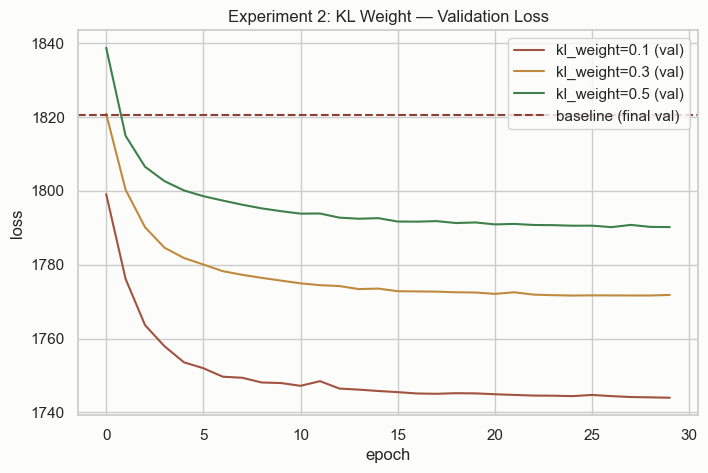

In [72]:
# Plot each variant's validation loss curve against the baseline's, on the same axes.
fig, ax = plt.subplots(figsize=(8, 5))
for i, kw in enumerate(kl_weight_variants):
    ax.plot(exp2_histories[kw]["val_loss"], label=f"kl_weight={kw} (val)", color=PALETTE[i])
ax.axhline(baseline_results["final_val_loss"], color=PALETTE[6], linestyle="--", label="baseline (final val)")
ax.set_xlabel("epoch")
ax.set_ylabel("loss")
ax.set_title("Experiment 2: KL Weight — Validation Loss")
ax.legend()
plt.show()

### Conclusion

None of the lower kl_weight variants beat the baseline's quality score (0.295): 0.1→0.235, 0.3→0.275, 0.5→0.260 despite much lower validation loss (1744–1790 vs. baseline's 1820). It's not monotonic either (0.3 beats both 0.1 and 0.5).

In summary, weakening the KL term sacrifices latent structure, so sampling from N(0,1) at generation time gets worse even as reconstruction loss drops. Quality score rules out all three; the baseline's kl_weight=1.0 is kept for the Section 10 final model. If a lower kl_weight had to be picked anyway, 0.3 is the best tradeoff of the three, closest to baseline's quality score while still cutting loss substantially, whereas 0.1 chases the lowest loss at the steepest quality cost.

## 6. Experiment 3: Architecture Depth

Our baseline VAE had a very shallow conv stack (2 layers, bottlenecking at 8x8). We propose a deeper architecture — a third conv/deconv layer pair, doubling channels at each downsample and bottlenecking at 4x4 instead — so the encoder/decoder has more room to discover features and textures (edges, then textures, then parts) that a single shallow stack can't easily separate out.

In [ ]:
# Deeper Encoder/Decoder: one extra conv/deconv layer pair vs. baseline, doubling channels per downsample, bottlenecking at 4x4 instead of 8x8.
class DeepEncoder(nn.Module):
    def __init__(self, num_classes, latent_dim):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(3 + num_classes, 32, kernel_size=3, stride=2, padding=1),  # 32x32 -> 16x16
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1),  # 16x16 -> 8x8
            nn.ReLU(),
            nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1),  # 8x8 -> 4x4
            nn.ReLU(),
        )
        self.fc_mean = nn.Linear(128 * 4 * 4, latent_dim)
        self.fc_log_var = nn.Linear(128 * 4 * 4, latent_dim)
        self.sampling = Sampling()

    def forward(self, x, y):
        y_map = y.view(y.size(0), -1, 1, 1).expand(-1, -1, x.size(2), x.size(3))
        x = torch.cat([x, y_map], dim=1)

        features = self.conv(x).flatten(start_dim=1)
        z_mean = self.fc_mean(features)
        z_log_var = self.fc_log_var(features)
        z = self.sampling(z_mean, z_log_var)
        return z_mean, z_log_var, z


class DeepDecoder(nn.Module):
    def __init__(self, num_classes, latent_dim):
        super().__init__()
        self.fc = nn.Linear(latent_dim + num_classes, 128 * 4 * 4)
        self.deconv = nn.Sequential(
            nn.ConvTranspose2d(128, 64, kernel_size=3, stride=2, padding=1, output_padding=1),  # 4x4 -> 8x8
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, kernel_size=3, stride=2, padding=1, output_padding=1),  # 8x8 -> 16x16
            nn.ReLU(),
            nn.ConvTranspose2d(32, 3, kernel_size=3, stride=2, padding=1, output_padding=1),  # 16x16 -> 32x32
            nn.Sigmoid(),
        )

    def forward(self, z, y):
        x = torch.cat([z, y], dim=1)
        x = self.fc(x).view(-1, 128, 4, 4)
        return self.deconv(x)


# Build and train a CVAE identical to baseline except for the deeper encoder/decoder (latent_dim, kl_weight held at baseline's values).
encoder = DeepEncoder(num_classes, baseline_results["latent_dim"])
decoder = DeepDecoder(num_classes, baseline_results["latent_dim"])
exp3_cvae = CVAE(encoder, decoder, kl_weight=baseline_results["kl_weight"])
exp3_cvae, exp3_history = train_cvae(exp3_cvae)

In [ ]:
# Generate a sample of images and preview them for eye-test scoring (same c/m/n criteria as the baseline).
exp3_images, exp3_labels = generate_class_images(exp3_cvae, baseline_results["latent_dim"])
preview_grid(exp3_images, exp3_labels, title="Deeper Architecture")

In [ ]:
# Fill in a c/m/n score for each of the 10 previewed images per class, based on the grid above.
exp3_eye_test_scores = {name: ["n"] * 10 for name in class_names}

In [ ]:
# Score with score_from_labels() (Section 3.1) and log quality score + val loss into the shared results dict.
scores_flat = [label for scores in exp3_eye_test_scores.values() for label in scores]
results["exp3_deeper_architecture"] = {
    "quality_score": score_from_labels(scores_flat),
    "val_loss": exp3_history["val_loss"][-1],
    "fid": None,  # FID is only tracked for baseline and final model
}

pd.DataFrame(results).T

In [ ]:
# Plot this experiment's validation loss curve against the baseline's, on the same axes.
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(exp3_history["val_loss"], label="deeper architecture (val)", color=PALETTE[2])
ax.axhline(baseline_results["final_val_loss"], color=PALETTE[6], linestyle="--", label="baseline (final val)")
ax.set_xlabel("epoch")
ax.set_ylabel("loss")
ax.set_title("Experiment 3: Architecture Depth — Validation Loss")
ax.legend()
plt.show()

### Notes

One sentence stating whether this experiment's quality score beat the baseline's and whether the loss curves suggest a healthier or worse fit than baseline.


## 7. Experiment 4: Color vs. Grayscale

Hypothesis (linked to the assignment's discussion question): converting inputs to grayscale removes color as a distinguishing cue, so the quality score should drop for classes that rely heavily on color (e.g. distinguishing cat/dog/deer by fur tone) but may hold up or even simplify shape-dominant classes (e.g. airplane, ship) — this experiment answers the question empirically rather than by reasoning alone.


In [ ]:
# Convert the training images to grayscale (single channel) and adjust the decoder's output channels accordingly.

In [ ]:
# Build and train a CVAE identical to baseline except for the single-channel input/output.

In [ ]:
# Generate a sample of images, score with score_from_labels() (Section 3.1) split by class, and log quality score + val loss into the results dict.

In [ ]:
# Plot this experiment's training/validation loss curves against the color baseline's, on the same axes.

### Discussion: Color vs. Grayscale, Empirically

One sentence stating whether this experiment's quality score confirmed or contradicted the prediction made in `vae_baseline.ipynb` Section 11.4, with the per-class score breakdown as evidence.


## 8. Experiment 5: Engineered Conditioning Features

Hypothesis: a bare one-hot label only tells the model "which of 10 buckets," so concatenating each class's mean per-channel color statistics (from `vae_eda.ipynb` Section 5) alongside the one-hot vector should raise the quality score by giving the encoder/decoder a richer, more informative conditioning signal — checked against the risk that the auxiliary features are redundant with what one-hot already encodes, or introduce noise if not genuinely informative.


In [ ]:
# Compute each class's mean per-channel (R, G, B) statistics from the training set, building a small per-class auxiliary feature vector.

In [ ]:
# Build and train a CVAE identical to baseline except the conditioning input is [one-hot label, auxiliary color-stats vector] instead of one-hot alone.

In [ ]:
# Generate a sample of images, score with score_from_labels() (Section 3.1), and log quality score + val loss into the results dict.

In [ ]:
# Plot this experiment's training/validation loss curves against the baseline's, on the same axes.

### Notes

One sentence stating whether the engineered conditioning features raised the quality score over the baseline's plain one-hot conditioning.


## 9. Experiment 6: Data Augmentation

Hypothesis: augmentation (e.g. random horizontal flip) exposes the model to more visual variation per class without collecting new data, so training with it should raise the quality score by reducing overfitting to the exact 5000 training images per class — checked against the risk that some flips are semantically wrong for a class (e.g. a flipped digit-like feature or an asymmetric object) and could confuse conditioning rather than help it.


In [ ]:
# Define an augmentation pipeline (e.g. random horizontal flip) applied to the training set only.

In [ ]:
# Build and train a CVAE identical to baseline except the training set is passed through the augmentation pipeline.

In [ ]:
# Generate a sample of images, score with score_from_labels() (Section 3.1), and log quality score + val loss into the results dict.

In [ ]:
# Plot this experiment's training/validation loss curves against the baseline's, on the same axes.

### Notes

One sentence stating whether augmentation raised the quality score over the baseline and whether the loss curves show reduced overfitting.


## 10. Final Model

One sentence stating the goal: apply the decision rule from Section 3.3 to combine the winning settings from experiments 1-3, 5, and 6 (latent_dim, kl_weight, depth, engineered conditioning, augmentation) into the single final model — Experiment 4 (color vs. grayscale) targets a discussion question, not a quality lever, so it's evaluated separately and not folded into the combination. This is the only model besides the baseline whose weights get saved.


### 10.1 Select Best Settings


In [ ]:
# Read each experiment's quality score/val loss from the results dict, and pick the best setting per axis using the Section 3.3 decision rule.

### 10.2 Train the Final Model


In [ ]:
# Build and train a CVAE using the combined best settings from 10.1 (no weights saved yet — training only).

In [ ]:
# Save the final model's weights to .h5 — the deliverable weights file for Part A, alongside the baseline's.

### 10.3 Evaluate the Final Model


In [ ]:
# Generate 1000 images (100/class) with the final model, score with score_from_labels(), and log into the results dict against the baseline.

In [ ]:
# Compute FID between real validation images and the final model's 1000 generated images (same InceptionV3 extractor as baseline), log into the results dict.

In [ ]:
# Plot the final model's training/validation loss curves against the baseline's, on the same axes.

### Notes

One sentence naming the final model's quality score and FID against the baseline's, stating the size of the improvement (or lack of one).


## 11. Ablation Summary

One sentence noting this table pulls the shared results dict into one place, so the final model's choice is backed by numbers already computed during the experiments, not a new comparison step.


In [ ]:
# Build one ablation table from the results dict: baseline, each experiment, and the final model, with quality score, val loss, and FID (baseline/final only) as columns.

In [ ]:
# Bar chart comparing quality scores across all models.

## 12. Conclusion

One sentence summarizing which single changes raised the quality score and which didn't (per the Section 3 metrics), and how much the final model gained over the baseline — noting its weights are saved to .h5 as the Part A deliverable, alongside the baseline's, and that this notebook's final results feed `vae_gan_comparison.ipynb`.
